# Random Forest

In [1]:
import warnings
import time
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
from typing import Iterable

from sklearn.ensemble import RandomForestClassifier

import json

warnings.filterwarnings('ignore')

DATA_PATH = './data_numpy'
BEST_PARAMS_PATH = './best_params/RF'

In [2]:
Xtr = pd.read_csv(f'./{DATA_PATH}/Xtr_encoded.csv')
Xval = pd.read_csv(f'./{DATA_PATH}/Xval_encoded.csv')
Xte = pd.read_csv(f'./{DATA_PATH}/Xte_encoded.csv')
ytr = pd.read_csv(f'./{DATA_PATH}/ytr.csv')
yval = pd.read_csv(f'./{DATA_PATH}/yval.csv')
yte = pd.read_csv(f'./{DATA_PATH}/yte.csv')


Xtr_oversampled = pd.read_csv(f'./{DATA_PATH}/Xtr_resampled_encoded.csv')
Xval_oversampled = pd.read_csv(f'./{DATA_PATH}/Xval_resampled_encoded.csv')
Xte_oversampled = pd.read_csv(f'./{DATA_PATH}/Xte_resampled_encoded.csv')
ytr_oversampled = pd.read_csv(f'./{DATA_PATH}/ytr_resampled_encoded.csv')
yval_oversampled = pd.read_csv(f'./{DATA_PATH}/yval_resampled_encoded.csv')
yte_oversampled = pd.read_csv(f'./{DATA_PATH}/yte_resampled_encoded.csv')

# Cross Validation

estimated completion time: $\approx 1$ hour 

In [13]:
from functools import reduce
from operator import mul
from sklearn.model_selection import ParameterGrid


def CV(
        Xtr: pd.DataFrame, ytr: pd.Series,
        Xval: pd.DataFrame, yval: pd.Series,
        n_estimators: Iterable,
        max_depth: Iterable,
        min_samples_split: Iterable,
        min_samples_leaf: Iterable,
        max_features: Iterable,
        random_state=1
):
    best_score = -1
    best_params = None

    param_grid = {
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'max_features': max_features,
        'criterion': ['gini', 'entropy']
    }

    # Cross validate only the trees
    param_grid["max_depth"] = [8]
    param_grid["min_samples_split"] = [4]
    param_grid["min_samples_leaf"] = [4]
    param_grid["max_features"] = ["log2"]

    fits = reduce(mul, [len(param) for param in param_grid.values()])

    for i, params in enumerate(ParameterGrid(param_grid)):
        timer = time.time()

        model = RandomForestClassifier(
            **params, random_state=random_state, n_jobs=-1)
        model.fit(Xtr, ytr)

        # probabilities for class 1
        y_pred_pr = model.predict_proba(Xval)[:, 1]
        y_pred = model.predict(Xval)

        roc_score = metrics.roc_auc_score(yval, y_pred_pr)
        f1_score = metrics.f1_score(yval, y_pred)

        end = time.time() - timer
        elapsed_time = f"{end:.1f}s" if end < 60 else f"{(end / 60):.1f}min"
        print(
            f"[fit {i+1}/{fits}] f1_score={f1_score:.6f} roc_auc={roc_score:.6f} total time=   {elapsed_time}")

        if f1_score > best_score and roc_score > 0.8:
            best_score = f1_score
            best_params = params

    return best_params, best_score

In [3]:
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [3, 5, 8],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features": ['sqrt', 'log2']
}
best_score = None

choice = input("Do you want to execute this cell? (yes/no): ")
if choice.lower() == "yes":
    print("Executing cross validation...")
    best_params, best_score = CV(
        Xtr, ytr, Xval, yval, **param_grid)
    with open(f"{BEST_PARAMS_PATH}/best_params.json", "w") as f:
        json.dump(best_params, f)
else:
    print("Loading data locally...")
    with open(f"{BEST_PARAMS_PATH}/best_params.json", "r") as f:
        best_params = json.load(f)

print(f"\nBest params:")
print(json.dumps(best_params, indent=2))
if best_score:
    print(f"Best score: {best_score:.3f}")

Loading data locally...

Best params:
{
  "max_depth": 16,
  "max_features": "sqrt",
  "min_samples_leaf": 1,
  "min_samples_split": 2,
  "n_estimators": 300,
  "split_criterion": "entropy"
}


In [4]:
best_params["criterion"] = best_params["split_criterion"]
del best_params["split_criterion"]

model_settings = {
    "n_jobs": -1,
    "verbose": 0
}

In [ ]:
model = RandomForestClassifier(**best_params, **model_settings, random_state=1)
model.fit(Xtr, ytr)

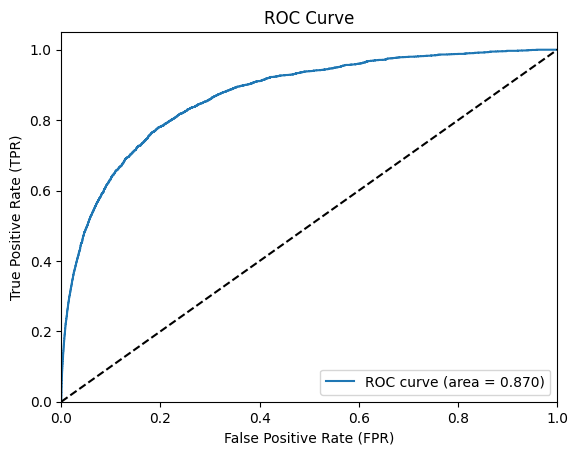

In [5]:
y_pred = model.predict_proba(Xte)[:, 1]  # probabilities for class 1
fpr, tpr, th = metrics.roc_curve(yte, y_pred)
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [6]:
y_pred_f1 = model.predict(Xte)

f1 = metrics.f1_score(yte, y_pred_f1, average=None)
precision = metrics.precision_score(yte, y_pred_f1, average=None)
recall = metrics.recall_score(yte, y_pred_f1, average=None)
# overall precision
precision_avg = metrics.precision_score(yte, y_pred_f1, average='weighted')
recall_avg = metrics.recall_score(yte, y_pred_f1, average='weighted')
f1_avg = metrics.f1_score(yte, y_pred_f1, average='weighted')
acc = metrics.accuracy_score(yte, y_pred_f1)

print(f'''
Class wise metrics:
{f1=}
{precision=}
{recall=}

Overall metrics
{f1_avg=}
{precision_avg=}
{recall_avg=}
''')


Class wise metrics:
f1=array([9.92895257e-01, 6.96864111e-04])
precision=array([0.98589561, 0.5       ])
recall=array([9.99995010e-01, 3.48675035e-04])

Overall metrics
f1_avg=0.9788961573797634
precision_avg=0.9790400212071998
recall_avg=0.9858908260852454



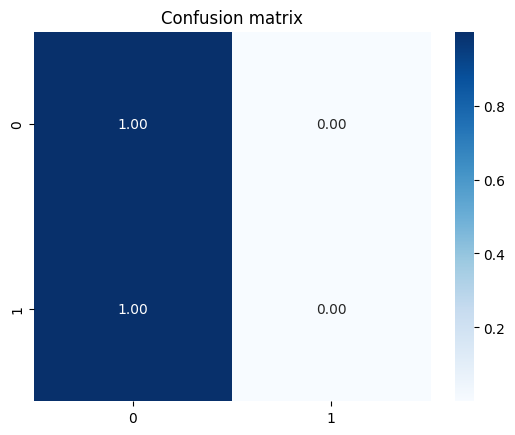

In [7]:
import seaborn as sns

cm = metrics.confusion_matrix(yte, y_pred_f1)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.title("Confusion matrix")
sns.heatmap(cm_norm, annot=True, fmt=".5f", cmap="Blues")
plt.show()

## Oversampled datasets

In [8]:
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [3, 5, 8],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features": ['sqrt', 'log2']
}
best_score = None

choice = input("Do you want to execute this cell? (yes/no): ")
if choice.lower() == "yes":
    print("Executing cross validation...")
    best_params, best_score = CV(
        Xtr_oversampled, ytr_oversampled, Xval_oversampled, yval_oversampled, **param_grid)
    with open(f"{BEST_PARAMS_PATH}/../oversampling/RF/best_params.json", "w") as f:
        json.dump(best_params, f)
else:
    print("Loading data locally...")
    with open(f"{BEST_PARAMS_PATH}/../oversampling/RF/best_params.json", "r") as f:
        best_params = json.load(f)

print(f"\nBest params:")
print(json.dumps(best_params, indent=2))
if best_score:
    print(f"Best score: {best_score:.3f}")

Loading data locally...

Best params:
{
  "max_depth": 16,
  "max_features": "sqrt",
  "min_samples_leaf": 2,
  "min_samples_split": 14,
  "n_estimators": 200,
  "split_criterion": "entropy"
}


In [9]:
best_params["criterion"] = best_params["split_criterion"]
del best_params["split_criterion"]

In [10]:
model = RandomForestClassifier(**best_params, **model_settings, random_state=1)
model.fit(Xtr_oversampled, ytr_oversampled)

RandomForestClassifier(criterion='entropy', max_depth=16, min_samples_leaf=2,
                       min_samples_split=14, n_estimators=200, n_jobs=-1,
                       random_state=1)

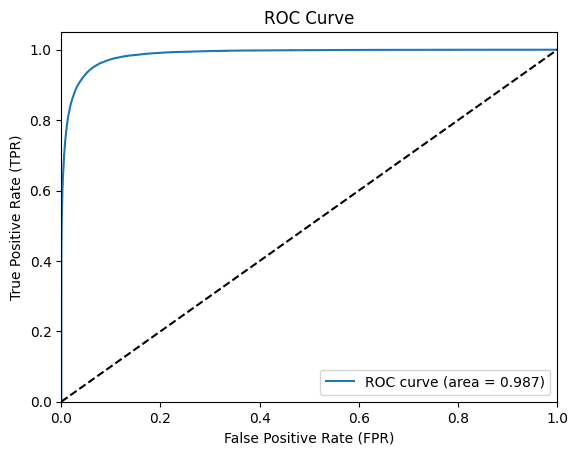

In [11]:
y_pred = model.predict_proba(Xte_oversampled)[
    :, 1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte_oversampled, y_pred)
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [12]:
y_pred_f1 = model.predict(Xte_oversampled)

f1 = metrics.f1_score(yte_oversampled, y_pred_f1, average=None)
precision = metrics.precision_score(yte_oversampled, y_pred_f1, average=None)
recall = metrics.recall_score(yte_oversampled, y_pred_f1, average=None)
# overall precision
precision_avg = metrics.precision_score(
    yte_oversampled, y_pred_f1, average='weighted')
recall_avg = metrics.recall_score(
    yte_oversampled, y_pred_f1, average='weighted')
f1_avg = metrics.f1_score(yte_oversampled, y_pred_f1, average='weighted')
acc = metrics.accuracy_score(yte_oversampled, y_pred_f1)

print(f'''
Class wise metrics:
{f1=}
{precision=}
{recall=}

Overall metrics
{f1_avg=}
{precision_avg=}
{recall_avg=}
''')


Class wise metrics:
f1=array([0.92395583, 0.93375237])
precision=array([0.88473358, 0.97126362])
recall=array([0.96681703, 0.89903083])

Overall metrics
f1_avg=0.9293935394976494
precision_avg=0.9327633052254541
recall_avg=0.9291913385774326



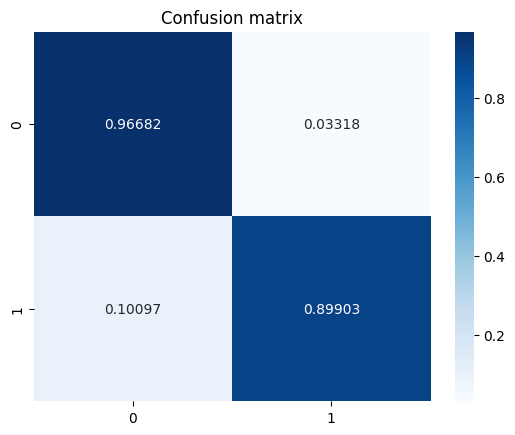

In [13]:
import seaborn as sns

cm = metrics.confusion_matrix(yte_oversampled, y_pred_f1)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.title("Confusion matrix")
sns.heatmap(cm_norm, annot=True, fmt=".5f", cmap="Blues")
plt.show()